# Supplementary Figure 1

*Carvalho, Cojocaru and Fukai (2026)*

**See also:** `figure2_upload.ipynb` (results with `alpha` = 0.0693).

## 📌 User input: start here!

### 1️⃣ Exponential gap penalty

Supplementary figures use `alpha` 0.1386 (5 ms).

### 2️⃣ Date

This notebook requires the output `run_all.py` and `movement_classes.py`. After verifying that both scripts have run, update the date of the result folder.

In [ ]:
alpha = "0.1386"
date_str = "20XX-XX-XX"

## Imports

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from statannotations.Annotator import Annotator
from scipy.stats import wilcoxon

from import_data import import_run_all
from plot_style import *

sessions = ["071102", "071107", "071109", "071213", 
            "071214", "071218", "071221", "071227", 
            "080213", "071228", "080206", "080208", 
            "080227", "080220", "080222"]

file_name = "run_all"
path_local = "../"

path_in = path_local + "results/" + date_str + "/" + file_name + "/"

path_out = path_local + "results/" + date_str + "/paper_plots/"
if not os.path.exists(path_out):
    os.makedirs(path_out)

path_plots = path_out + f"figure2_alpha{alpha}/"
if not os.path.exists(path_plots):
    os.makedirs(path_plots)

path_out_movement = path_local + "results/movement_classes/"

(
    df_stage,
    df_comparison,
    df_neuron_concat,
    df_edge_concat,
    df_profile_concat,
    df_reward_concat_full,
    df_reward_combined_concat_full,
    df_reward_concat_prof_len,
) = import_run_all(
    sessions,
    alpha,
    path_in,
    path_out_movement,
    export=True,
)

# Helpers

In [3]:
class TestChoice:
    def __init__(self, name: str, kwargs: dict):
        self.name = name
        self.kwargs = kwargs


def plot_paired_boxplot(df, column, export_name, test_choice, path_plots, swarm=True, lines=True):
    fig, ax = plt.subplots(1, 1, figsize=(2.5, 4))

    fig_args = {
        'x': 'Stage',
        'y': column,
        'data': df,
        'order': ["Early", "Late"],
        'hue': 'Stage',
        'linewidth': 2.5,
        'palette': palette_early_late,
        'flierprops': {
            "marker": "x", 
            "markersize": 12, 
            "markerfacecolor": color_markers, 
            "markeredgecolor": color_markers
        }
    }
    sns.boxplot(ax=ax, **fig_args)

    if swarm:
        sns.swarmplot(data=df, x='Stage', y=column, color=color_markers, size=6)
    if lines:
        sns.lineplot(data=df, x='Stage', y=column, units='Session', estimator=None, color=color_lines, alpha=0.5)

    # Specify comparison
    significanceComparisons = [(("Early"), ("Late"))]

    # Configure and apply test
    configuration = {'test': test_choice.name,
                    'comparisons_correction': None,
                    'text_format': 'star',
                    'pvalue_format_string': "p={:.3g}",
                    'loc': 'outside',
                    'show_test_name': False,}
    annotator = Annotator(ax=ax, pairs=significanceComparisons, **fig_args, plot='barplot')
    annotator.configure(**configuration).apply_test(**test_choice.kwargs).annotate()

    ax.set_ylabel(column)
    ax.set_xlabel("")
    sns.despine(bottom=True)

    fig.savefig(path_plots + "earlylate_" + export_name + "_paired.pdf", bbox_inches="tight", dpi=300)


def plot_unpaired_boxplot(df, column, export_name, test_choice, path_plots, swarm=True):
    fig, ax = plt.subplots(1, 1, figsize=(2.5, 4))

    fig_args = {
        'x': 'Stage',
        'y': column,
        'data': df,
        'order': ["Early", "Late"],
        'hue': 'Stage',
        'linewidth': 2.5,
        'palette': palette_early_late,
        'flierprops': {
            "marker": "x", 
            "markersize": 12, 
            "markerfacecolor": color_markers, 
            "markeredgecolor": color_markers
        }
    }
    sns.boxplot(ax=ax, **fig_args)

    if swarm:
        sns.swarmplot(data=df, x='Stage', y=column, color=color_markers, size=6)

    # Specify comparison
    significanceComparisons = [(("Early"), ("Late"))]

    # Configure and apply test
    configuration = {'test': test_choice.name,
                    'comparisons_correction': None,
                    'text_format': 'star',
                    'pvalue_format_string': "p={:.3g}",
                    'loc': 'outside',
                    'show_test_name': False,}
    annotator = Annotator(ax=ax, pairs=significanceComparisons, **fig_args, plot='barplot')
    annotator.configure(**configuration).apply_test(**test_choice.kwargs).annotate()

    ax.set_ylabel(column)
    ax.set_xlabel("")
    sns.despine(bottom=True)

    fig.savefig(path_plots + "earlylate_" + export_name + "_unpaired.pdf", bbox_inches="tight", dpi=300)


def plot_single_box(df, column, export_name, path_plots, swarm=True):
    fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))

    order = ["All"]

    fig_args = {
        'x': "All",
        'y': column,
        'data': df,
        'linewidth': 2.5,
        'color': palette_all[0],
        'flierprops': {
            "marker": "x", 
            "markersize": 12, 
            "markerfacecolor": color_markers, 
            "markeredgecolor": color_markers
        }
    }
    sns.boxplot(ax=ax, order=order, **fig_args)

    if swarm:
        sns.swarmplot(
        data=df,
        x="All",
        y=column,
        color=color_markers,
        order=order,
        size=6,
        ax=ax
    )

    sns.despine(bottom=True)
    ax.set_xlabel("")

    fig.savefig(path_plots + "earlylate_" + export_name + "_all.pdf", bbox_inches="tight", dpi=300)  


# Panel B

In [4]:
df = df_profile_concat[df_profile_concat["Method"] == "Profile"]
df_early = df[df["Stage"] == "Early"]
df_late = df[df["Stage"] == "Late"]

summary = pd.concat({
        "Early": df_early[["Length", "Spike count"]].describe().loc[["count", "mean", "std", "min", "max"]],
        "Late": df_late[["Length", "Spike count"]].describe().loc[["count", "mean", "std", "min", "max"]],
    }, axis=1
)

print(summary.round(2))

        Early                Late            
       Length Spike count  Length Spike count
count  223.00      223.00  284.00      284.00
mean     3.35        3.53    3.20        3.43
std      0.76        0.93    0.46        0.73
min      3.00        3.00    3.00        3.00
max      7.00        7.00    5.00        8.00


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Early vs. Late: t-test paired samples, P_val:2.735e-01 t=-1.140e+00


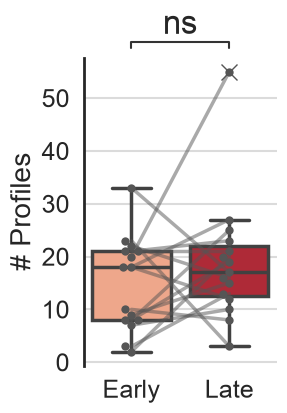

In [16]:
column = "# Profiles"
df = df_stage[df_stage["Method"] == "Profile"].copy()
export_name = "num_profiles"
test_choice = TestChoice('t-test_paired', {'alternative': 'two-sided'})

plot_paired_boxplot(df, column, export_name, test_choice, path_plots)

# Panel C

In [6]:
df = df_stage[df_stage["Method"] == "Profile"].copy()
df_early = df[df["Stage"] == "Early"].copy()
df_late = df[df["Stage"] == "Late"].copy()

summary = pd.DataFrame({
    stage_name: {
        "# Neurons in Graph": d["# Neurons in Graph"].sum(),
        "# Neurons Below FR Max": d["# Neurons Below FR Max"].sum(),
        "Percentage": d["# Neurons in Graph"].sum() / d["# Neurons Below FR Max"].sum() * 100,
    }
    for stage_name, d in [("All", df), ("Early", df_early), ("Late", df_late)]
})

print(summary.round(2))

                            All    Early     Late
# Neurons in Graph       588.00   293.00   295.00
# Neurons Below FR Max  4391.00  2192.00  2199.00
Percentage                13.39    13.37    13.42


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Early vs. Late: t-test paired samples, P_val:9.049e-01 t=1.216e-01


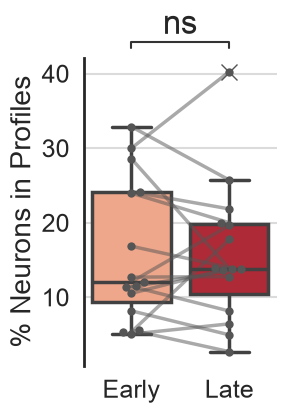

In [17]:
column = "% Neurons in Profiles"
df = df_stage[df_stage["Method"] == "Profile"].copy()
export_name = "perc_neu_in_prof"
test_choice = TestChoice('t-test_paired', {'alternative': 'two-sided'})

plot_paired_boxplot(df, column, export_name, test_choice, path_plots)

# Panel D

In [8]:
df_profile_clean = (df_profile_concat[df_profile_concat["Method"] == "Profile"].copy())
df_profile_clean["Frequency (Hz)"] = df_profile_clean["Sequence count"] / (20 * 60)

df_profile_clean_early = df_profile_clean[df_profile_clean["Stage"] == "Early"].copy()
df_profile_clean_late = df_profile_clean[df_profile_clean["Stage"] == "Late"].copy()

mean_early = df_profile_clean_early["Frequency (Hz)"].mean()
std_early = df_profile_clean_early["Frequency (Hz)"].std()
mean_late = df_profile_clean_late["Frequency (Hz)"].mean()
std_late = df_profile_clean_late["Frequency (Hz)"].std()

print("=== Profile frequency ===")
print(f"Early: mean {mean_early.round(3)}, std {std_early.round(3)}")
print(f"Late: mean {mean_late.round(3)}, std {std_late.round(3)}")

=== Profile frequency ===
Early: mean 0.018, std 0.015
Late: mean 0.022, std 0.023


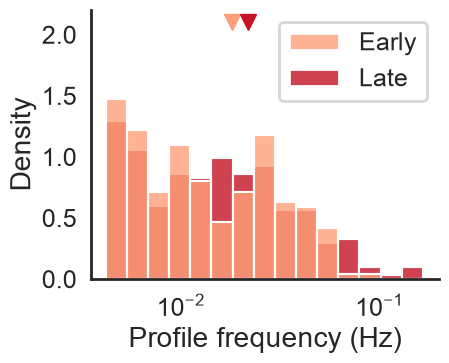

In [9]:
fig, ax = plt.subplots(1, sharey=True, figsize=(4.5,3.5))

sns.histplot(data=df_profile_clean, x="Frequency (Hz)", bins=15, hue="Stage", log_scale=True, 
             alpha=0.8, common_norm=False, common_bins=True, palette=palette_early_late, 
             stat="density")

ax.get_legend().set_title("")
ax.grid(False)
ax.set_xlim(3.5e-3, 2e-1)

ax.plot(mean_early, 2.1, marker="v", color=color_early, markersize=12)
ax.plot(mean_late, 2.1, marker="v", color=color_late, markersize=12)

ax.set_xlabel("Profile frequency (Hz)")

sns.despine(left=False, bottom=False)

fig.savefig(path_plots + "earlylate_profile_frequency.pdf", bbox_inches="tight", dpi=300)

=== Pooled frequencies ===
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Early vs. Late: Mann-Whitney-Wilcoxon test two-sided, P_val:1.863e-01 U_stat=2.950e+04


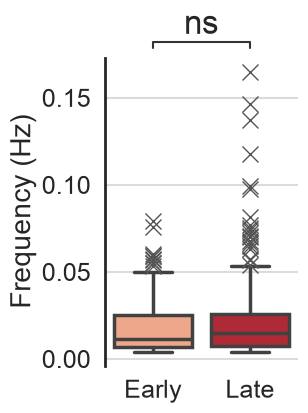

In [10]:
print("=== Pooled frequencies ===")

column = "Frequency (Hz)"
df = df_profile_clean[df_profile_clean["Method"] == "Profile"].copy()
export_name = "prof_freq"
test_choice = TestChoice('Mann-Whitney', {'alternative': 'two-sided', 'use_continuity': True})

plot_unpaired_boxplot(df, column, export_name, test_choice, path_plots, swarm=False)

In [11]:
print("=== Session-level median frequencies ===")

df_profile_local = df_profile_clean[df_profile_clean["Method"] == "Profile"].copy()

session_frequency = (
    df_profile_local.groupby(["Session", "Stage"])["Frequency (Hz)"]
      .median().unstack("Stage").dropna(subset=["Early", "Late"])
)

W, p = wilcoxon(session_frequency["Early"], session_frequency["Late"], alternative="two-sided")
print("W =", W, "p =", p.round(4))

=== Session-level median frequencies ===
W = 51.5 p = 0.6292


# Panel E

In [12]:
df = df_stage[df_stage["Method"] == "Profile"].copy()
df["# Crosslayer Profiles"] = df["# Profiles"] - df["# Shallow Profiles"] - df["# Deep Profiles"]

total_profiles = df["# Profiles"].sum()

summary = pd.DataFrame({
    "Count": {
        "Crosslayer": df["# Crosslayer Profiles"].sum(),
        "Shallow": df["# Shallow Profiles"].sum(),
        "Deep": df["# Deep Profiles"].sum(),
        "Total": total_profiles,
    },
})
summary["Percentage"] = summary["Count"] / total_profiles * 100

print(summary.round(2))

            Count  Percentage
Crosslayer  373.0       73.57
Shallow     100.0       19.72
Deep         34.0        6.71
Total       507.0      100.00


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Early vs. Late: t-test paired samples, P_val:3.008e-01 t=-1.074e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Early vs. Late: Wilcoxon test (paired samples), P_val:1.849e-01 Stat=1.450e+01


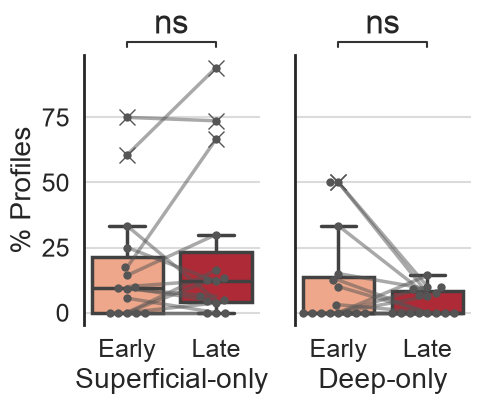

In [18]:
df = df_stage[df_stage["Method"] == "Profile"].copy()
export_name = "num_profiles"

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(5, 3.5))

fig_args = {'x': 'Stage',
            'y': '% Superficial Profiles',
            'data': df,
            'order': ["Early", "Late"],
            'hue': 'Stage',
            'linewidth': 2.5,
            'palette': palette_early_late,
            'flierprops': {"marker": "x", "markersize": 12, "markerfacecolor": color_markers, "markeredgecolor": color_markers}}
sns.boxplot(ax=ax[0], **fig_args) 

test_choice1 = TestChoice('t-test_paired', {'alternative': 'two-sided'})

sns.swarmplot(data=df, x='Stage', y="% Superficial Profiles", color=color_markers, size=6, ax=ax[0])
sns.lineplot(data=df, x='Stage', y="% Superficial Profiles", units='Session', color=color_lines, alpha=0.5, estimator=None, ax=ax[0])

significanceComparisons = [(("Early"), ("Late"))]

configuration = {'test': test_choice1.name,
                    'comparisons_correction': None,
                    'text_format': 'star',
                    'pvalue_format_string': "p={:.3g}",
                    'loc': 'outside',
                    'show_test_name': False}

annotator = Annotator(ax=ax[0], pairs=significanceComparisons, **fig_args, plot='boxplot')
annotator.configure(**configuration).apply_test(**test_choice1.kwargs).annotate()

ax[0].set_xlabel("Superficial-only")
ax[0].set_ylabel("% Profiles")

fig_args = {'x': 'Stage',
            'y': '% Deep Profiles',
            'data': df,
            'order': ["Early", "Late"],
            'hue': 'Stage',
            'linewidth': 2.5,
            'palette': palette_early_late,
            'flierprops': {"marker": "x", "markersize": 12, "markerfacecolor": color_markers, "markeredgecolor": color_markers}}
sns.boxplot(ax=ax[1], **fig_args)

test_choice2 = TestChoice('Wilcoxon', {'alternative': 'two-sided', 'zero_method': 'wilcox'})

sns.swarmplot(data=df, x='Stage', y="% Deep Profiles", color=color_markers, size=6, ax=ax[1])
sns.lineplot(data=df, x='Stage', y="% Deep Profiles", units='Session', color=color_lines, alpha=0.5, estimator=None, ax=ax[1])

configuration = {'test': test_choice2.name,
                    'comparisons_correction': None,
                    'text_format': 'star',
                    'pvalue_format_string': "p={:.3g}",
                    'loc': 'outside',
                    'show_test_name': False}

annotator = Annotator(ax=ax[1], pairs=significanceComparisons, **fig_args, plot='boxplot')
annotator.configure(**configuration).apply_test(**test_choice2.kwargs).annotate()

ax[1].set_xlabel("Deep-only")
ax[1].set_ylabel("")
sns.despine(bottom=True)

fig.savefig(path_plots + "earlylate_supdeep_perc_prof.pdf", bbox_inches="tight", dpi=300)

# Panel F

In [14]:
df = df_comparison[df_comparison["Method"] == "Profile"].copy()

summary = pd.Series({
    "# Persistent Neurons": df["# Persistent Neurons"].sum(),
    "# Neurons in Graphs": df["# Neurons in Graphs"].sum(),
    "Percentage": df["# Persistent Neurons"].sum() / df["# Neurons in Graphs"].sum() * 100,
}, name="Total")

print(summary.round(2).to_frame())

                       Total
# Persistent Neurons  109.00
# Neurons in Graphs   479.00
Percentage             22.76


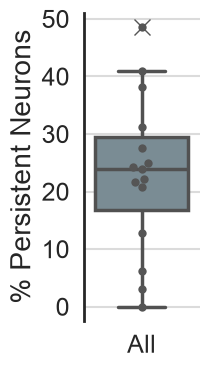

In [15]:
df = df_comparison[df_comparison["Method"] == "Profile"].copy()
df["All"] = "All"
column = "% Persistent Neurons"
export_name = "perc_persistent_neu"

plot_single_box(df, column, export_name, path_plots)